<a href="https://colab.research.google.com/github/tokiror/maple-scholars-2026/blob/main/CHIRPS_vs_SPEI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kongwa Climate Analysis — CHIRPS Rainfall & SPEI Drought (2002–2022)

Part of the **Maple Scholars 2024** project (Kevin Liddell & Drew Hackman), following up on
the Tanzania Mycotoxin Mitigation Study (MMS). This notebook builds monthly rainfall and
drought time series for Kongwa district and its surrounding region, to test whether
agro-climatic conditions during the 2019–2020 study window help explain the trial's
aflatoxin results.

> **Working hypothesis (from the MMS follow-up):** healthier growing conditions →
> stronger plant defense → lower mycotoxin levels. These climate series are the evidence
> base for evaluating that idea. See *Interpretation* notes under each figure.

---

## Data sources

| Dataset | Earth Engine ID | Variable used | Native scale |
|---|---|---|---|
| CHIRPS (pentad rainfall) | `UCSB-CHG/CHIRPS/PENTAD` | precipitation (mm) | ~5 km |
| SPEI 2.10 (CSIC) | `CSIC/SPEI/2_10` | `SPEI_12_month` | ~55 km |
| District boundaries | `projects/ee-gc-gis/assets/DistrictShapefiles` | Kongwa polygon | vector |

**Study period:** 2002-01-01 to 2022-12-31 (252 months).
**Study window of interest:** 2019–2020 (shaded in all figures).

---

## Pipeline / run order

Run the cells top to bottom. Each step depends on the ones before it.

1. **Authenticate & initialize Earth Engine** — opens a session under the `ee-gc-gis` project.
2. **Define Kongwa geometry & analysis boxes** — locate the district and build nested regions.
3. **Build monthly CHIRPS rainfall** — sum pentads into monthly totals.
4. **Define extraction helpers** — reduce rasters to per-region time series.
5. **Extract all regions** — run the helpers over every box (slowest step).
6. **Plot** — three figures (A, B, C below).

---

## Cell-by-cell description

### 1. Earth Engine authentication & initialization
Authenticates with Google Earth Engine and initializes the session under the `ee-gc-gis`
cloud project. Must run first — every later cell depends on an active EE session. Anyone
re-running the notebook needs their own EE access to this project.

### 2. Kongwa district geometry & concentric analysis boxes
Loads the district shapefile asset, isolates Kongwa, and computes its centroid
(lon **36.545°**, lat **−6.012°**). Defines four nested square regions around that centroid
via the `box(hw)` helper — the study district plus three progressively wider "rings" — so
climate signals can be compared at the local scale versus the surrounding region.

The `rings` values (`0.25, 0.5, 1.0, 2.0`) are **half-widths** in degrees. Each box therefore
spans twice that on a side (e.g. the "Kongwa (~0.25 deg)" box is ~0.5° × 0.5°). See
*Known issues* on the label wording.

### 3. CHIRPS monthly rainfall preparation
Loads the CHIRPS pentad collection for 2002–2022 (**1,512** pentad images) and rebuilds it
into **252** monthly totals by summing all pentads within each month. Produces
`chirpsMonthly`, an `ImageCollection` tagged with `YYYY-MM-dd` dates, ready for regional
extraction.

### 4. Time-series extraction helpers (`extract_chirps`, `extract_spei`)
Two functions that reduce a raster collection to a mean value per time step over a given
geometry and return a tidy pandas DataFrame:
- `extract_chirps(geom)` → monthly rainfall (`rain_mm`), reduced at ~5 km scale.
- `extract_spei(geom)` → 12-month SPEI (`SPEI_12`) from CSIC SPEI 2.10, reduced at ~55 km scale.

The differing scales are intentional — each matches its source's native resolution.

### 5. Regional extraction loop
Iterates over the four boxes, filling `rain_series` and `spei_series` (dictionaries keyed by
region name). This step pulls data from Earth Engine to the client, so it is the slowest cell
and the one most likely to time out on a weak connection.

---

## Figures

### Figure A — CHIRPS Monthly Rainfall: Kongwa vs wider regions (2002–2022)
Monthly rainfall for Kongwa and the three surrounding boxes, overlaid, with the 2019–2020
window shaded. X-axis: year; Y-axis: rainfall (mm/month).

> _Interpretation (DRAFT — your call):_ The four series track each other closely, suggesting
> Kongwa's rainfall regime is representative of the wider region at these scales. Rainfall in
> the 2019–2020 window appears at or above the typical seasonal peak.

### Figure B — SPEI-12: Kongwa vs wider regions (2002–2022)
The 12-month SPEI for the same regions. Dashed line at 0 = historical mean; positive = wetter
than normal, negative = drought, in standard deviations. Because SPEI-12 integrates a full
year, it moves slowly and reveals multi-year wet/dry regimes rather than monthly noise.

> _Interpretation (DRAFT — your call):_ The 2019–2020 window coincides with a strongly
> **positive** SPEI-12 (approaching ~+2), i.e. an anomalously **wet** period — not a drought.
> This is central to the mycotoxin question and worth stating explicitly: a wet regime could
> support the "healthier plants" logic, but excess moisture can also raise fungal/mycotoxin
> risk depending on crop and timing. Decide which reading your evidence supports.

### Figure C — Kongwa: Rainfall vs SPEI-12, dual axis (2002–2022)
Monthly rainfall (blue bars, left axis) against SPEI-12 (orange line, right axis) for Kongwa
alone. Shows how short-term rainfall accumulates into the slower-moving moisture balance.

> _Interpretation (DRAFT — your call):_ Sustained wet stretches (bar clusters) precede the
> rises in SPEI-12; the 2019–2020 peak follows a run of strong rainfall years.

---

## Requirements

- Python 3.x with `earthengine-api`, `pandas`, `matplotlib`
- A Google Earth Engine account with access to the `ee-gc-gis` project
- The `DistrictShapefiles` asset available under that project

Authenticate once with `ee.Authenticate()`, then run top to bottom.

---

## Known issues / TODO

- [ ] **Ring labels are half-widths.** Labels like "Kongwa (~0.25 deg)" describe the
  half-width, not the box size (actual span ~0.5°). Reword the labels or add a comment so
  readers don't misjudge the spatial scale.
- [ ] **Dead code:** `monthly_rain(year, month)` is defined but never called — monthly
  compositing is actually done by the `months.map(...)` block. Remove it (and note it uses a
  different date format, `'YY '` vs `'YYYY-MM-dd'`) to avoid confusion.

In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project ='ee-gc-gis')

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#Kongwa district and center
districts = ee.FeatureCollection('projects/ee-gc-gis/assets/DistrictShapefiles')
Kongwa = districts.filter(ee.Filter.eq('District_N', 'Kongwa'))
center = Kongwa.geometry().centroid(10)
coords = center.coordinates().getInfo()
print(coords)
lon0, lat0 = coords[0], coords[1]
print(f'Kongwa center: lon {lon0:3f}, lat{lat0:3f}')
rings = {
    'Kongwa (~0.25 deg)': 0.25,
    'Ring 1 (~0.5 deg)':  0.5,
    'Ring 2 (~1.0 deg)':  1.0,
    'Ring 3 (~2.0 deg)':  2.0,
}
def box(hw):
    return ee.Geometry.Rectangle([lon0-hw, lat0-hw, lon0+hw, lat0+hw])

[36.545352903049796, -6.012014573338543]
Kongwa center: lon 36.545353, lat-6.012015


In [ ]:
#CHIRPS monthly rainfall data
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD').filterDate('2002-01-01','2022-12-31')
print(chirps.size().getInfo())
def monthly_rain( year, month):
  start = ee.Date.fromYMD(year, month, 1)
  end = start.advance(1, 'month')
  return chirps.filterDate(start, end).sum().set('date', start.format('YY '))
months = ee.List.sequence(0, 12*21 - 1).map(lambda n: ee.Date('2002-01-01'). advance(n, 'month'))
chirpsMonthly = ee.ImageCollection(months.map(lambda d: (
    chirps.filterDate(ee.Date(d), ee.Date(d).advance(1,'month')).sum()
          .set('date', ee.Date(d).format('YYYY-MM-dd'))
)))

1512


In [ ]:
#SPEI
speiCol = ee.ImageCollection('CSIC/SPEI/2_10').filterDate('2002-01-01','2022-12-31')

#  Extract CHIRPS rainfall time series for a geometry
def extract_chirps(geom):
    def per_img(img):
        val = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=geom, scale=5000, bestEffort=True)
        return ee.Feature(None, {'date': img.get('date'), 'rain_mm': val.get('precipitation')})
    fc = ee.FeatureCollection(chirpsMonthly.map(per_img))
    rows = [f['properties'] for f in fc.getInfo()['features']]
    d = pd.DataFrame(rows)
    d['date'] = pd.to_datetime(d['date'])
    d['rain_mm'] = pd.to_numeric(d['rain_mm'], errors='coerce')
    return d.sort_values('date').reset_index(drop=True)

#  Extract SPEI-12 time series for a geometry
def extract_spei(geom):
    def per_img(img):
        val = img.select('SPEI_12_month').reduceRegion(
            reducer=ee.Reducer.mean(), geometry=geom, scale=55000, bestEffort=True)
        return ee.Feature(None, {'date': img.date().format('YYYY-MM-dd'),
                                 'SPEI_12': val.get('SPEI_12_month')})
    fc = ee.FeatureCollection(speiCol.map(per_img))
    rows = [f['properties'] for f in fc.getInfo()['features']]
    d = pd.DataFrame(rows)
    d['date'] = pd.to_datetime(d['date'])
    d['SPEI_12'] = pd.to_numeric(d['SPEI_12'], errors='coerce')
    return d.sort_values('date').reset_index(drop=True)


Extracting Kongwa (~0.25 deg) ...
Extracting Ring 1 (~0.5 deg) ...
Extracting Ring 2 (~1.0 deg) ...
Extracting Ring 3 (~2.0 deg) ...
Done.


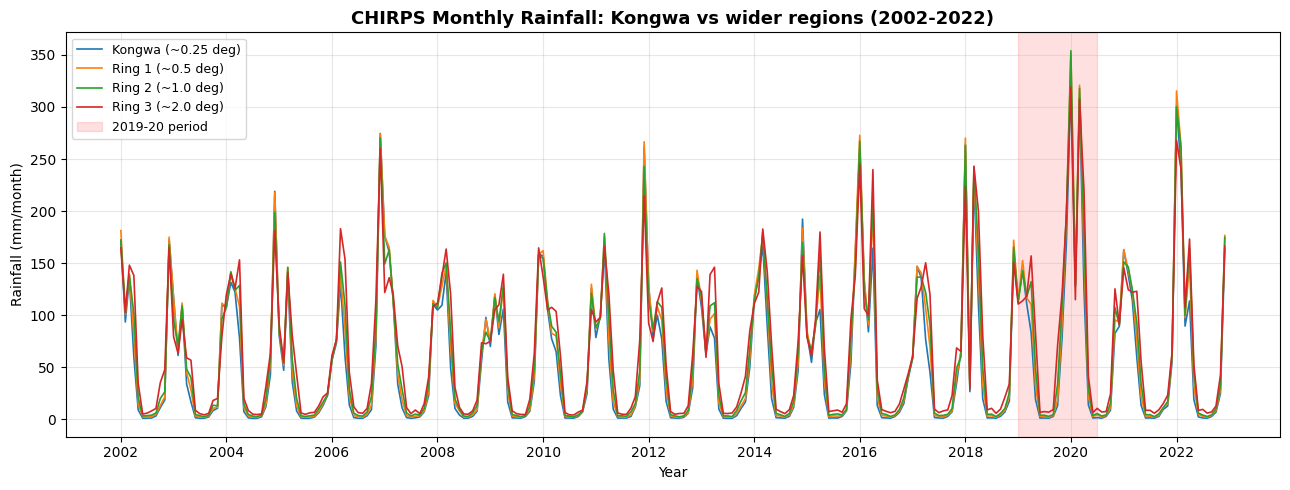

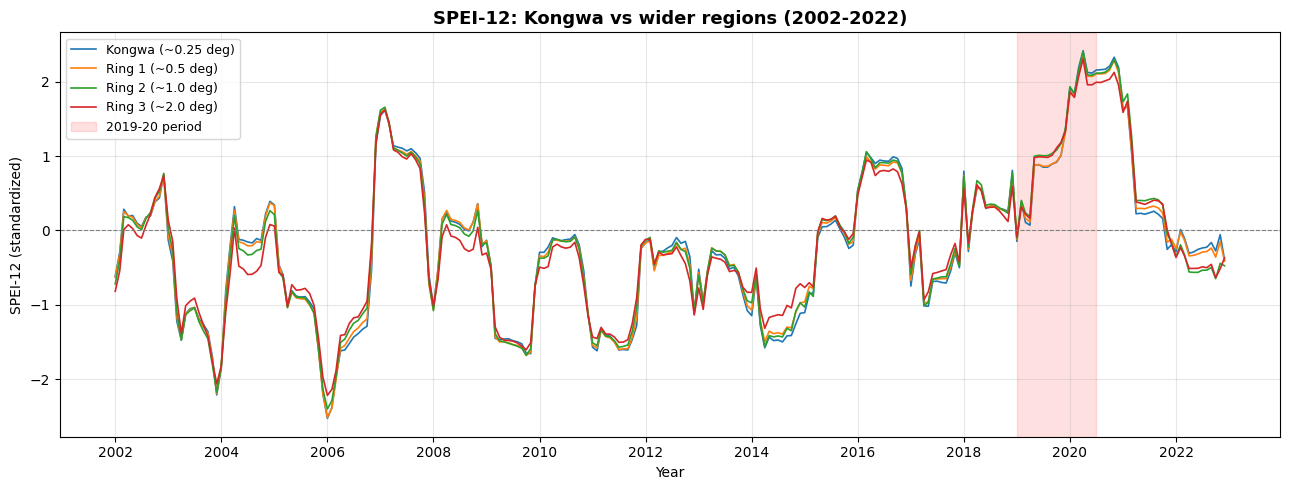

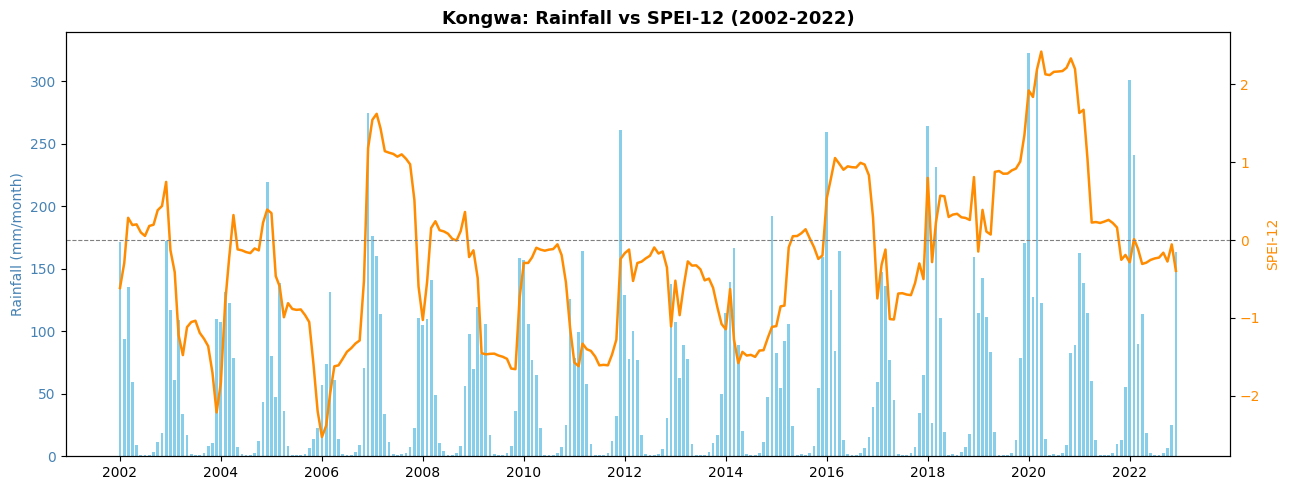

In [ ]:
rain_series, spei_series = {}, {}
for name, hw in rings.items():
    print("Extracting", name, "...")
    g = box(hw)
    rain_series[name] = extract_chirps(g)
    spei_series[name] = extract_spei(g)
print("Done.")

# CHIRPS rainfall, all rings overlaid ---
fig, ax = plt.subplots(figsize=(13,5))
for name in rings:
    ax.plot(rain_series[name]['date'], rain_series[name]['rain_mm'], lw=1.2, label=name)
ax.axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2020-06-30'), alpha=0.12, color='red', label='2019-20 period')
ax.set_title('CHIRPS Monthly Rainfall: Kongwa vs wider regions (2002-2022)', fontsize=13, weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Rainfall (mm/month)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

# SPEI-12
fig, ax = plt.subplots(figsize=(13,5))
for name in rings:
    ax.plot(spei_series[name]['date'], spei_series[name]['SPEI_12'], lw=1.2, label=name)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2020-06-30'), alpha=0.12, color='red', label='2019-20 period')
ax.set_title('SPEI-12: Kongwa vs wider regions (2002-2022)', fontsize=13, weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('SPEI-12 (standardized)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

# Kongwa only — rainfall and SPEI together (dual axis) ---
fig, ax = plt.subplots(figsize=(13,5))
k = 'Kongwa (~0.25 deg)'
ax.bar(rain_series[k]['date'], rain_series[k]['rain_mm'], width=20, color='skyblue', label='Rainfall (mm)')
ax.set_ylabel('Rainfall (mm/month)', color='steelblue'); ax.tick_params(axis='y', labelcolor='steelblue')
ax2 = ax.twinx()
ax2.plot(spei_series[k]['date'], spei_series[k]['SPEI_12'], color='darkorange', lw=1.8, label='SPEI-12')
ax2.axhline(0, color='gray', ls='--', lw=0.8)
ax2.set_ylabel('SPEI-12', color='darkorange'); ax2.tick_params(axis='y', labelcolor='darkorange')
ax.set_title('Kongwa: Rainfall vs SPEI-12 (2002-2022)', fontsize=13, weight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()